/content/CryoEM_membranes_top_model_decision_tree
[main 808d8f5] Updated root folder
 1 file changed, 326 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 12 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 3.98 KiB | 3.98 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree.git
   505  main -> main


# Top Model Decision Tree

### ⚠️ Google Colab A100 GPU Only Notebook

This notebook is designed to run in **Google Colab with A100 GPU**. To start using this notebook, clone this GitHub repo in Colab:
```
!git clone https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree.git
```
✅ It requires:
- A100 GPU runtime (CUDA) for memory, inference speed tests
- Linux environment
- Colab-specific install steps (e.g., `!pip install`, `!git clone`, `from google.colab.patches import cv2_imshow`)

❌ Running locally (especially on Windows) may fail due to:
- Detectron2 installation issues
- CUDA/toolchain mismatches
- Missing compiled operators
                            
![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)
(https://colab.research.google.com/github/Lynnicia/CryoEM_membranes_top_model_decision_tree/blob/main/top_model_decision_tree.ipynb)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
!git clone https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree.git

/content
Cloning into 'CryoEM_membranes_top_model_decision_tree'...
remote: Enumerating objects: 747, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 747 (delta 109), reused 81 (delta 73), pack-reused 612 (from 3)
Receiving objects: 100% (747/747), 186.99 MiB | 68.53 MiB/s, done.
Resolving deltas: 100% (304/304), done.


##Step 1. Load in models and test images

### 🌱 Prepare notebook for model seeds and model architectures 🌱

 ```
          @@@@@@@@@@@@@@@@@@@@@
       @@@@@@@@@@@@@@@@@@@@@@@@@@@
    @@                             @@
  @@    @@@@@  @@@@@  @@@@@  @@@     @@
 @@    @       @      @      @  @     @@
 @@    @@@@@   @@@    @@@    @   @    @@
 @@         @  @      @      @   @    @@
  @@   @@@@@   @@@@@  @@@@@  @@@@    @@
   @@                              @@
      @@@@@@@@@@@@@@@@@@@@@@@@@@@@
         @@@@@@@@@@@@@@@@@@@@@@
```


### Load in LD and ULD best model checkpoints into notebook (~5-30 min load time):

In [3]:
%cd /content/CryoEM_membranes_top_model_decision_tree/seed/models
%run /content/CryoEM_membranes_top_model_decision_tree/seed/models/model_repo.ipynb


/content/CryoEM_membranes_top_model_decision_tree/seed/models
--2026-04-12 18:29:55--  https://github.com/Lynnicia/CryoEM_membranes_top_model_decision_tree/releases/download/640-YOLOv11-LD/640-YOLOv11-LD.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1139374969/f4ed4f74-7d85-4f96-90c3-863cd464393d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T19%3A13%3A57Z&rscd=attachment%3B+filename%3D640-YOLOv11-LD.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-12T18%3A13%3A46Z&ske=2026-04-12T19%3A13%3A57Z&sks=b&skv=2018-11-09&sig=kCMybqVMt6Kk6mcEOEb4IB%2BUM1TCFZ4vMBNIPNV2DWc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiw

### Load in LD and ULD model seeds into notebook:

In [4]:
%cd /content/CryoEM_membranes_top_model_decision_tree

from seed import LD_models, ULD_models
from seed.LD_models import MODEL_MAP as LD_MODEL_MAP
from seed.ULD_models import MODEL_MAP as ULD_MODEL_MAP

MODEL_MAP = {
    **LD_MODEL_MAP,
    **ULD_MODEL_MAP,
}

print(MODEL_MAP)

/content/CryoEM_membranes_top_model_decision_tree
{('LD', 640): <function model_LD_640 at 0x7fba400413a0>, ('LD', 1024): <function model_LD_1024 at 0x7fba400414e0>, ('ULD', 640): <function model_ULD_640 at 0x7fba40041760>, ('ULD', 1024): <function model_ULD_1024 at 0x7fba40041620>}



### Load in model architectures into notebook:
This code run will load in YOLOv11, YOLO26, U-Net, Detectron2 and SAM3 fine-tuned pre-trained models. If code does not work, restart the noteobok and load the models again.

In [5]:
#If the session restarts, re-run the module
%cd /content/CryoEM_membranes_top_model_decision_tree
%run /content/CryoEM_membranes_top_model_decision_tree/seed/model_arch.ipynb

/content/CryoEM_membranes_top_model_decision_tree
Loading YOLOv11 and YOLO26...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ YOLOv11 and YOLO26 model architectures loaded
Loading U-Net...
✓ U-Net architecture loaded
Loading Detectron2...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 7.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while ge

### 💧 Prepare Notebook for Test Images💧

### Drop in test images into notebook:

What test images do you have? Select dose and image size

Dose: ("LD", "ULD")

Image Size: (640, 1024)   640 is for speed, 1024 is for detail

In [45]:
test_electron_dose_decision = "LD"      # options: "LD", "ULD"

test_image_size_decision = 1024      # options: 640, 1024 (no quotes!)



Input if this is a custom dataset. If so, add path, text (needed for YOLO) and json (needed for COCO)

In [46]:
#OPTIONAL CUSTOM IMAGES, SKIP IF NOT USING A CUSTOM DATASET (test folder including images and optinoally a single .json file)

custom_dataset = "NO"        # default "NO". If using a custom dataset, type "YES"

custom_dataset_folder = "/content/my_custom_dataset/test"

custom_dataset_text = "/content/my_custom_dataset/test/test.txt"      # YOLO only

custom_dataset_json =  "/content/my_custom_dataset/test/_annotations.coco.json"      # COCO only



#Do not touch below!~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


%cd /content/CryoEM_membranes_top_model_decision_tree

#from drop import drop_test_images
from drop.coco_bacteria_dataset import CocoBacteriaDataset
from torch.utils.data import DataLoader
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances

if custom_dataset == "YES":
    from drop import custom_test_images

import pandas as pd
import numpy as np
import cv2
import glob
import os
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

if custom_dataset == "NO":
    from drop import LD_test_images, ULD_test_images
    from drop.LD_test_images import TEST_MAP as LD_TEST_MAP
    from drop.ULD_test_images import TEST_MAP as ULD_TEST_MAP

    TEST_MAP = {
        **LD_TEST_MAP,
        **ULD_TEST_MAP,
    }

    print(TEST_MAP)

if custom_dataset == "YES":
    from drop import LD_custom_test_images, ULD_custom_test_images
    from drop.LD_custom_test_images import TEST_MAP as LD_TEST_MAP
    from drop.ULD_custom_test_images import TEST_MAP as ULD_TEST_MAP

    TEST_MAP = {
        **LD_TEST_MAP,
        **ULD_TEST_MAP,
    }

    print(TEST_MAP)



#--------------------

test_loader, test_image_dir, test_images_yv11, test_images_y26, test_img_folder, test_ann_path, test_images_orig_folder = TEST_MAP[(test_electron_dose_decision, test_image_size_decision)]()



/content/CryoEM_membranes_top_model_decision_tree
{('LD', 640): <function test_image_LD_640 at 0x7fb8d0f7f240>, ('LD', 1024): <function test_image_LD_1024 at 0x7fb8d0f7f2e0>, ('ULD', 640): <function test_image_ULD_640 at 0x7fb8d0f7f6a0>, ('ULD', 1024): <function test_image_ULD_1024 at 0x7fb8d0f7f740>}
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


# Prpare the Top Model Table with masks and metrics of test images

```

#
#                               %%%%%%%
#                        %%%%%%%%%%%%%%%%%
#                       %%%%%%%%%%%%%%%%%%%%%%%
#                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#                  %%%%%|     |%%/   \%%|   \%%%%%%%%
#                 %%%%%%%%| |%%%| |%| |%| *_/%%%%%%%
#                %%%%%%%%%| |%%%%\   /%%| |%%%%%%%
#                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#                    %%%%%%%%%%%\%%|%%/%%%%%%%%%
#                         %%%%   \|||/  %%%%
#                                 |||
#                                 |||
#                                 |||
#                                 |||
#                              ___|||___
#  ######################## __//  |||  \\___ #######################
"""#################### // |Tree Root START| \\ ####################"""
"""################## // ######## ||| ######## \\ ##################"""
```

##Step 2. Select mask count

##### How many bacteria are in your test images? Manually count your test images and input the count below:

(20 count is for LD test images and 65 count for ULD images)

Then, run mask prediction below:

Pick LD model set, ULD model set or both for the predictions:

("LD", "ULD")

In [77]:
manual_count = 20

model_electron_dose_decision = "LD"      # options: "LD", "ULD"




#Do not touch below!~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


model_image_size_decision = 640     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":
    results_folder = "/content/CryoEM_membranes_top_model_decision_tree/Masks_LD"
    os.makedirs(results_folder, exist_ok=True)
    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)

elif model_electron_dose_decision == "ULD":
    results_folder = "/content/CryoEM_membranes_top_model_decision_tree/Masks_ULD"
    os.makedirs(results_folder, exist_ok=True)
    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)

else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")

model_image_size_decision = 1024     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":
    results_folder = "/content/CryoEM_membranes_top_model_decision_tree/Masks_LD"
    os.makedirs(results_folder, exist_ok=True)
    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)


elif model_electron_dose_decision == "ULD":
    results_folder = "/content/CryoEM_membranes_top_model_decision_tree/Masks_ULD"
    os.makedirs(results_folder, exist_ok=True)
    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)


else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")

/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/Camera-Falcon-1942-Falconn_dyn_png.rf.699b53b7d31c718b73d9616a9938c9e0.jpg: 2 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/95_Camera-Falcon-2315-Falcon_R2A_dyn_png.rf.af6094fad7ac17be33abb787cef55486.jpg: 1 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/Camera-Falcon-0352-Falcon_dyn_png.rf.9cf8c43be360fe9e369c6bf25fae29b4.jpg: 1 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/Camera-Falcon-2313-0002-Falcon_dyn_png.rf.c187ffd6757e37c8e3530669d7791449.jpg: 3 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/Camera-Falcon-1628-Falcon_dyn_png.rf.f83a4009bfaf20de3f9445f5836c27c9.jpg: 1 bacteria
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images/Camera-Falcon-0301-Falcon_dyn_png.rf.3cc98932636b2b940247e06d40e4b6b8.jpg: 2 bacter

Plot model predicted bacteria count compared with manual count:

/tmp/ipykernel_1263/945362063.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


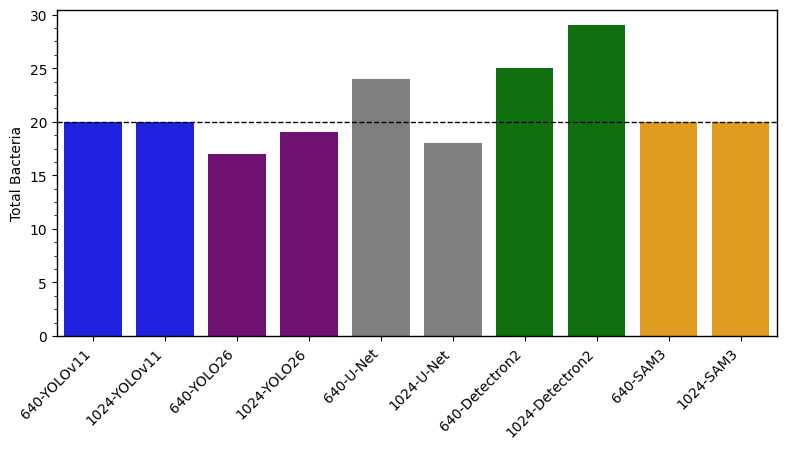

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = "/content/CryoEM_membranes_top_model_decision_tree/top_model_table.csv"
df = pd.read_csv(csv_path)


dfs_ld = df[
    (df["Test_Electron_Dose"] == test_electron_dose_decision) &
    (df["Test_Image_Size"] == test_image_size_decision) &
    (df["Model_Electron_Dose"] == model_electron_dose_decision)
]
color_map = {
    "U-Net": "grey",
    "YOLOv11": "blue",
    "YOLO26": "purple",
    "Detectron2": "green",
    "SAM3": "orange"
}

g = sns.catplot(
    data=dfs_ld,
    kind="bar",
    x="Model",
    y="total_bacteria",
    hue="Model_Architecture",
    palette=color_map,
    errorbar=None,
    height=4,
    aspect=2,
    legend=False
)

for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

g.set_axis_labels("", "Total Bacteria")

from matplotlib.ticker import AutoMinorLocator

for ax in g.axes.flat:
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))  # 2 minor ticks between majors
    ax.tick_params(axis='x', which='minor', length=3)

for ax in g.axes.flat:
    ax.axhline(manual_count, color='black', linestyle='--', linewidth=1)
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

### Step 3. Evaluate metrics and speed

Prepare speed test (clear GPU cache)

1.   List item
2.   List item



metrics

speed

In [99]:


model_image_size_decision = 640     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":


    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.speed_decision_tree_yv11 import run_model_speed_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_speed_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.speed_decision_tree_y26 import run_model_speed_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_speed_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.speed_decision_tree_u import run_model_speed_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_speed_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)
"""
    # Detectron2
    input_folder = test_img_folder
    from root.speed_decision_tree_d2 import run_model_speed_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_speed_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.speed_decision_tree_s3 import run_model_speed_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_speed_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)

elif model_electron_dose_decision == "ULD":

    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)
    """
"""    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)

else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")

model_image_size_decision = 1024     # (no quotes!)
MODEL_PATH_u, MODEL_PATH_yv11, MODEL_PATH_y26, MODEL_PATH_d2, MODEL_PATH_s3 = MODEL_MAP[(model_electron_dose_decision, model_image_size_decision)]()

if model_electron_dose_decision == "LD":

    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)


elif model_electron_dose_decision == "ULD":

    Model_Image_Size = model_image_size_decision
    Model_Electron_Dose = model_electron_dose_decision
    Test_Image_Size = test_image_size_decision
    Test_Electron_Dose = test_electron_dose_decision
    TARGET_FOLDER = results_folder

    # YOLOv11
    input_folder = test_images_orig_folder
    from root.mask_decision_tree_yv11 import run_model_pipeline_yv11
    Model = f"{model_image_size_decision}-YOLOv11"
    run_model_pipeline_yv11(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_yv11, test_images_yv11, test_images_orig_folder)

    # YOLO26
    from root.mask_decision_tree_y26 import run_model_pipeline_y26
    Model = f"{model_image_size_decision}-YOLO26"
    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)

    # U-Net
    TARGET_SIZE = Test_Image_Size
    from root.mask_decision_tree_u import run_model_pipeline_u
    Model = f"{model_image_size_decision}-U-Net"
    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)

    # Detectron2
    input_folder = test_img_folder
    from root.mask_decision_tree_d2 import run_model_pipeline_d2
    Model = f"{model_image_size_decision}-Detectron2"
    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_d2, test_img_folder)

    #SAM3
    COUNTER = 1
    input_folder = test_ann_path
    from root.mask_decision_tree_s3 import run_model_pipeline_s3
    Model = f"{model_image_size_decision}-SAM3"
    run_model_pipeline_s3(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_s3, test_img_folder, test_ann_path)


else:
    raise ValueError("Invalid option: choose 'LD' or 'ULD'")"""

/content/CryoEM_membranes_top_model_decision_tree/seed/models/640-YOLOv11-LD.pt
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images
Speed test for 640-YOLOv11-LD:
Avg image time per image: 21.64 ms
FPS: 46.21
GPU Name: NVIDIA A100-SXM4-40GB
CUDA Version: 12.8
GPU Count: 1
Current Device: 0
Total Memory (GB): 42.405855232
Multiprocessors: 108
Compute Capability: 8.0
GPU: NVIDIA A100-SXM4-40GB
Total Memory (GB): 42.4 GB
CUDA Version: 12.8
Compute Capability: 8.0
CSV updated successfully to Tree ✅
/content/CryoEM_membranes_top_model_decision_tree/seed/models/640-YOLO26-LD.pt
/content/CryoEM_membranes_top_model_decision_tree/Datasets/LD/YOLO/test/images
Speed test for 640-YOLO26-LD:
Avg image time per image: 23.07 ms
FPS: 43.35
GPU Name: NVIDIA A100-SXM4-40GB
CUDA Version: 12.8
GPU Count: 1
Current Device: 0
Total Memory (GB): 42.405855232
Multiprocessors: 108
Compute Capability: 8.0
GPU: NVIDIA A100-SXM4-40GB
Total Memory (GB): 42.4 GB
CUDA Version: 12.8
Compute

'    # YOLO26\n    from root.mask_decision_tree_y26 import run_model_pipeline_y26\n    Model = f"{model_image_size_decision}-YOLO26"\n    run_model_pipeline_y26(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_y26, test_images_y26, test_images_orig_folder)\n \n    # U-Net\n    TARGET_SIZE = Test_Image_Size\n    from root.mask_decision_tree_u import run_model_pipeline_u\n    Model = f"{model_image_size_decision}-U-Net"\n    run_model_pipeline_u(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_PATH_u, test_loader, test_image_dir)\n\n    # Detectron2\n    input_folder = test_img_folder\n    from root.mask_decision_tree_d2 import run_model_pipeline_d2\n    Model = f"{model_image_size_decision}-Detectron2"\n    run_model_pipeline_d2(Model, Model_Image_Size, Model_Electron_Dose, Test_Image_Size, Test_Electron_Dose, input_folder, TARGET_FOLDER, MODEL_P

Plot model speed:

NameError: name 'circle_filled' is not defined

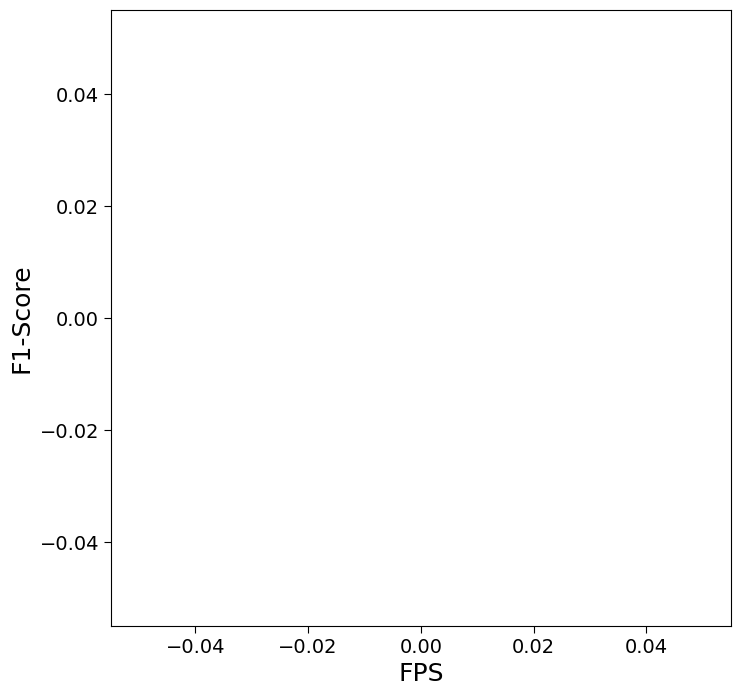

In [87]:
# O.F1-Score
import pandas as pd
import matplotlib.pyplot as plt


csv_path = "/content/CryoEM_membranes_top_model_decision_tree/top_model_table.csv"
df = pd.read_csv(csv_path)


#====================================================

# Scatter Plot


df["Model_Image_Size"] = pd.to_numeric(
    df["Model_Image_Size"],
    errors="coerce"
)
df = df.dropna(subset=["Model_Image_Size"])

df_640_sorted = (
    df[
        (df["Test_Image_Size"] == test_image_size_decision) &
        (df["Class"] == "All") &
        (df["Test_Electron_Dose"] == test_electron_dose_decision)
    ]
    .sort_values(by="FPS", ascending=False)
    .reset_index(drop=True)
)

color_map = {
    "U-Net": "grey",
    "YOLOv11": "blue",
    "YOLO26": "purple",
    "Detectron2": "green",
    "SAM3": "orange"
}


marker_map = {
    640: "o",
    1024: "s"
}

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,8))

for _, row in df_640_sorted.iterrows():

    arch = row["Model_Architecture"].strip()
    color = color_map.get(arch, "black")
    marker = marker_map.get(row["Model_Image_Size"], "o")

    facecolor = color if row["Model_Electron_Dose"] == "LD" else "none"

    plt.scatter(
        row["FPS"],
        row["O.F1-Score"],
        marker=marker,
        edgecolor=color,
        facecolor=facecolor,
        s=140,
        linewidth=2
    )
ax = plt.gca()

ax.tick_params(
    axis='both',        # x and y
    which='major',      # major ticks only
    length=5,           # remove tick marks
    labelsize=14        # control number size
)
plt.xlabel("FPS", fontsize=18)
plt.ylabel("F1-Score", fontsize=18)
#plt.title("Model Speed Performance Comparison")
plt.grid(False)

from matplotlib.legend_handler import HandlerTuple
import matplotlib.lines as mlines

# --- SIZE COMBO (circle + square) ---
circle = mlines.Line2D([], [], color='black', marker='o',
                      linestyle='None', markersize=8)

square = mlines.Line2D([], [], color='black', marker='s',
                      linestyle='None', markersize=8)

bbox_x = 1.01


# --- LEGEND 1 ---
legend_arch = ax.legend(
    handles=[
        mlines.Line2D([], [], linestyle='None', label='YOLOv11'),
        mlines.Line2D([], [], linestyle='None', label='YOLO26'),
        mlines.Line2D([], [], linestyle='None', label='Detectron2'),
        mlines.Line2D([], [], linestyle='None', label='SAM3'),
        mlines.Line2D([], [], linestyle='None', label='U-Net'),
    ],
    title="Model Architecture",
    loc="upper left",
    bbox_to_anchor=(bbox_x, 1),
    fontsize=10,
    title_fontsize=12,
    frameon=False,
    handlelength=0,
    handletextpad=0
)

for text in legend_arch.get_texts():
    text.set_color(color_map[text.get_text()])

ax.add_artist(legend_arch)

# --- LEGEND 2 ---
legend2 = ax.legend(
    [circle_filled, square_filled, circle_hollow, square_hollow],
    ["LD, 640", "LD, 1024", "ULD, 640", "ULD, 1024"],
    title="Electron Dose, Image Size",
    loc="upper left",
    bbox_to_anchor=(bbox_x, 0.65),
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

ax.add_artist(legend2)



# --- SPACE FOR LEGENDS ---
plt.tight_layout(rect=[0, 0, 0.75, 1])



#====================================================

# Bar Graph

import seaborn as sns
import matplotlib.pyplot as plt

dfs = df.sort_values("FPS", ascending=False)

color_map = {
    "U-Net": "grey",
    "YOLOv11": "blue",
    "YOLO26": "purple",
    "Detectron2": "green",
    "SAM3": "orange"
}

def color_bars(ax, subset):
    model_y = {t.get_text(): pos for pos, t in zip(ax.get_yticks(), ax.get_yticklabels())}

    for patch in ax.patches:
        bar_y = patch.get_y() + patch.get_height() / 2

        if not model_y:
            continue
        closest_model = min(model_y, key=lambda m: abs(model_y[m] - bar_y))

        matched = subset[subset["Model"] == closest_model]
        if matched.empty:
            continue

        tick_y = model_y[closest_model]
        is_ld = bar_y < tick_y

        arch = matched["Model_Architecture"].iloc[0]
        color = color_map.get(arch, "black")

        if is_ld:
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
        else:
            patch.set_facecolor("white")
            patch.set_edgecolor(color)
            patch.set_linewidth(1.5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

plt.rcParams["figure.dpi"] = 300

for size in [640, 1024]:
    subset = dfs[dfs["Test_Image_Size"] == size]

    g = sns.catplot(
        data=subset,
        kind="bar",
        y="Model",
        x="FPS",
        hue="Model_Electron_Dose",
        palette="light:gray",
        errorbar=None,
        height=5,
        aspect=1
    )

    ax = g.axes.flat[0]
    color_bars(ax, subset)
    ax.set_xlim(0, 140)
    g.legend.remove()

    g.set_axis_labels("FPS", "Model")
    ax.text(0.98, 0.02, f"Ultralow-dose Test Image Size: {size}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10)
    plt.tight_layout()
    plt.show()

In [97]:
import importlib
from root import speed_decision_tree_yv11

importlib.reload(speed_decision_tree_yv11)

<module 'root.speed_decision_tree_yv11' from '/content/CryoEM_membranes_top_model_decision_tree/root/speed_decision_tree_yv11.py'>

In [98]:
import importlib
from root import speed_decision_tree_y26

importlib.reload(speed_decision_tree_y26)

<module 'root.speed_decision_tree_y26' from '/content/CryoEM_membranes_top_model_decision_tree/root/speed_decision_tree_y26.py'>